# Phase 2.3 — GENROU + ST1A + PSS1A + TGOV1 on SMIB (the complete classical plant)

> **Phase 2.2 prerequisite.** This notebook builds on
> `phase2_2_pss.ipynb` — same operating point, same 50 Hz system,
> same TGR-tuned ST1A and PSS1A.  Phases 2.0–2.2 controlled the
> machine's *voltage* and *damping*; mechanical power $P_m$ was a
> constant frozen at its init value.  Phase 2.3 adds the **TGOV1
> steam turbine governor**, closing the last classical loop:
> **primary frequency response**.  $P_m$ is now a live model output.

Headline plots:

1. **Primary frequency response** (§7) — the grid loses generation
   (emulated by an infinite-bus angle ramp, $\Delta f = -0.2$ Hz).
   The rotor slip locks to the grid deviation and the governor
   raises $P_m$ by exactly $-\Delta\bar\omega/R = +0.08$ pu.  The
   measured droop line is recovered from simulation and overlaid on
   the design line $\Delta P_m = -\Delta\bar\omega / R$.
2. **Time-scale separation** (§8) — the same 200 ms deep fault as
   Phase 2.1/2.2, governor on vs off.  First-swing behaviour is
   *unchanged* (the valve cannot move in 200 ms) — the governor
   lives on a ~7.5 s reheat time scale, two decades slower than the
   swing.
3. **Valve ceiling + anti-windup** (§9) — a −2 % frequency event
   demands $\Delta P_m = +0.4$ pu but the valve has only +0.2 pu of
   headroom.  The non-windup limit pins the valve at $V_{max}$ and
   releases it cleanly on recovery.
4. **CCT (almost) preservation** (§10) — five-way comparison; the
   governor moves CCT by only a few ms (326 → 333 ms) — and in the
   *helpful* direction, because the valve's fast HP fraction dips
   $P_m$ slightly while the rotor accelerates through a near-CCT
   fault.


## 1. Imports

In [1]:
# Bootstrap so the smib package is importable from notebooks/.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here.parent if _here.name == 'notebooks' else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from smib.models import GENCLS, GENROU, TGOV1
from smib.models.st1a import ST1A
from smib.models.pss1a import PSS1A
from smib.network import Network
from smib.powerflow import two_bus_pf
from smib.scenarios import three_phase_fault_schedule, grid_frequency_ramp_schedule
from smib.simulator import (run_smib_genrou, run_smib_genrou_avr,
                            run_smib_genrou_avr_pss, run_smib_genrou_avr_pss_gov)
from smib.plotting import plot_sld


## 2. What's new — what a turbine governor actually does

Phase 2.2 closed the *electrical* control loops.  But step back and
ask: where does $P_m$ — the mechanical power on the left-hand side
of the swing equation — actually come from?

$$ 2H\,\frac{d\bar\omega}{dt} \;=\; P_m \;-\; P_e \;-\; D\,\bar\omega $$

In a steam plant, $P_m$ comes from high-pressure steam pushing on
turbine blades, and the *valve* between the boiler and the turbine
decides how much.  The **governor** is the controller that moves
that valve — and its input is **rotor speed**.

### Why speed?  The grid's oldest feedback loop

Every synchronous machine on an interconnection spins in lockstep at
system frequency.  If the system loses a generator (or gains load),
the remaining machines slow down *together* — the kinetic energy of
their rotors supplies the shortfall for the first few seconds (the
**inertial response** you already know from $2H$).  But inertia only
buys time; something must actually *replace* the lost megawatts.
That something is the governor on every machine simultaneously
feeling the speed drop and opening its valve: **primary frequency
response**.

### Droop — why not just regulate frequency to zero error?

A naive governor would integrate the speed error until frequency is
exactly 50 Hz again (an *isochronous* governor).  That works for one
machine feeding an island — and fails catastrophically the moment
two such machines share a grid: both integrators fight to set the
frequency, the dispatch between them is indeterminate, and the two
valves wind against each other.  The industry solution, unchanged
since the 1930s, is **droop**: make the governor a *proportional*
controller, deliberately leaving a small steady-state frequency
error, so that every machine's contribution is set by one number:

$$ \Delta P_m \;=\; -\,\frac{\Delta\bar\omega}{R} $$

$R$ is the droop, in pu frequency per pu power.  With the
near-universal $R = 0.05$ (5 %): a machine that sees frequency fall
1 % raises its output by 20 % of rating.  Every machine with the
same $R$ shares the burden *pro-rata to its rating* — automatic,
decentralised, no communication required.  (Restoring frequency the
last fraction of a Hz is *secondary* control — AGC — which
re-dispatches $P_{ref}$ minutes later and is out of scope for SMIB.)

### TGOV1 — the simplest faithful steam chain

$$ T_1\,\dot x_v \;=\; \Big(P_{ref} - \frac{\Delta\bar\omega}{R}\Big) - x_v
   \qquad\text{(valve servo, clamped } V_{min} \le x_v \le V_{max}) $$

$$ T_3\,\dot x_r \;=\; x_v - x_r
   \qquad\qquad
   P_m \;=\; \frac{T_2}{T_3}\,x_v + \Big(1-\frac{T_2}{T_3}\Big)\,x_r - D_t\,\Delta\bar\omega $$

| Parameter | Value | What it physically is |
|---|---|---|
| $R$    | 0.05   | droop — 5 %, the grid-code number |
| $T_1$  | 0.5 s  | valve/servo lag — how fast the gate physically moves |
| $T_2$  | 2.5 s  | reheat lead — the **high-pressure stage fraction** ($T_2/T_3 = 1/3$ of power responds at valve speed) |
| $T_3$  | 7.5 s  | **reheat time constant** — steam leaving the HP turbine must be re-heated before the IP/LP stages can use it |
| $V_{max}/V_{min}$ | 1.0 / 0.0 | valve travel — a steam valve cannot open past rated flow or go negative |
| $D_t$  | 0      | turbine damping (off) |

The lead-lag is the part worth internalising: when the valve steps,
**one third** of the power change arrives almost immediately (the HP
stage sits right behind the valve), and the remaining two thirds
arrive on the 7.5 s reheat lag.  You will see exactly this two-step
shape in §7.

The classical plant stack is now complete:

| Pillar | Function | smib model | Phase |
|---|---|---|---|
| Inertia + flux | swing equation, rotor flux | GENROU | 2.0 |
| Voltage regulation | terminal V control | ST1A | 2.1 |
| Damping | swing-mode damping torque | PSS1A | 2.2 |
| **Frequency response** | **mechanical power vs frequency** | **TGOV1** | **2.3 (here)** |


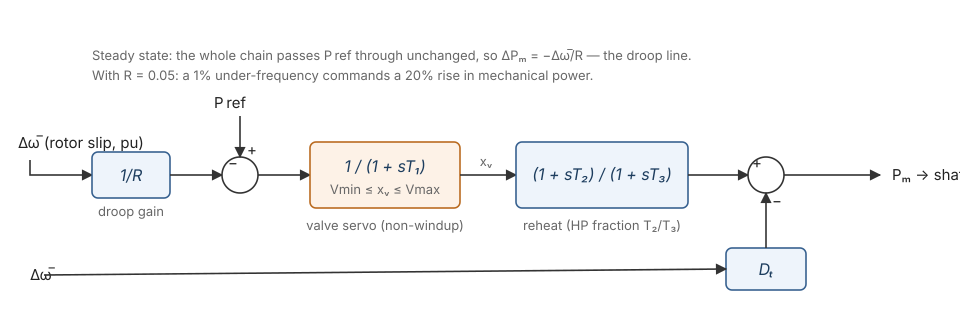

In [2]:
# TGOV1 block diagram — read this alongside the §2 prose.
from IPython.display import SVG, display
display(SVG(filename='figs/tgov1_block_diagram.svg'))


## 3. Operating point — identical to Phase 2.0 / 2.1 / 2.2

Same canonical point: $P = 0.8$, $Q = 0.2$ pu export over
$X_{line} = 0.5$ pu to a 1.0 pu infinite bus.  The Newton-Raphson
power flow solves the two-bus mismatch equations; the single-line
diagram makes the converged operating point readable at a glance.


In [3]:
P, Q = 0.8, 0.2
R_line, X_line = 0.0, 0.5
V_inf = 1.0 + 0j

V1, iters = two_bus_pf(P, Q, abs(V_inf), 0.0, R_line, X_line, bus_type='PQ')
print(f'PF converged in {iters} iters: V1 = {abs(V1):.4f} pu /_ {math.degrees(np.angle(V1)):.3f} deg')

fig = plot_sld(V_gen=V1, S_gen=complex(P, Q), V_inf=V_inf,
               R_line=R_line, X_line=X_line, gen_label='GENROU+ST1A+PSS1A+TGOV1',
               title='SMIB single-line diagram (Phase 2.3, post-LF)')
fig.show()


PF converged in 5 iters: V1 = 1.0178 pu /_ 23.142 deg


## 4. Initialisation — combined protocol, and the governor's one trap

Init order: GENROU first (derives $E_{fd,0}$ **and** $P_{m,0}$),
then ST1A (back-solves $V_{ref}$), then PSS1A (zeros), then TGOV1
(back-solves $P_{ref}$).  The combined system has **eleven**
differential states:

$$ x = [\;\underbrace{\delta,\;\bar\omega,\;E'_q,\;E'_d}_{\text{GENROU}},\;
       \underbrace{V_c,\;x_{LL}}_{\text{ST1A}},\;
       \underbrace{x_w,\;x_{LL1},\;x_{LL2}}_{\text{PSS1A}},\;
       \underbrace{x_v,\;x_r}_{\text{TGOV1}}\;] $$

**The governor's back-solve, by hand.**  At steady state
$\Delta\bar\omega = 0$, so the droop branch contributes nothing and
the whole chain is a unity pass-through of $P_{ref}$:

$$ x_v = P_{ref}, \qquad x_r = P_{ref}, \qquad
   P_m = \tfrac{T_2}{T_3} P_{ref} + (1 - \tfrac{T_2}{T_3}) P_{ref} = P_{ref}. $$

DAE consistency with the swing equation
($2H\,\dot{\bar\omega} = 0 \Rightarrow P_m = P_{e,0}$) then forces

$$ P_{ref} \;=\; P_{m,0} \;=\; P_{e,0} \;=\; V_d I_d + V_q I_q. $$

**The trap (master plan §5.2):** the droop gain $1/R$ multiplies
**only** $\Delta\bar\omega$ — never $P_{ref}$.  Wire $P_{ref}$
through the $1/R$ block and your governor is out by a factor of
$1/0.05 = 20$: either the machine takes off at init, or the
frequency response is 20× too weak.  The cell below does the manual
calculation and then the encapsulated `initialise()` side-by-side.


In [4]:
S = complex(P, Q)

# ---- manual back-calculation (the same five steps as Phase 2.0, ----
# ---- then the governor's pass-through)                          ----
I_term = np.conj(S / V1)
E_a    = V1 + 1j * 1.76 * I_term            # phasor behind Xq (Kundur X_q = 1.76)
delta0 = float(np.angle(E_a))
rot    = np.exp(-1j * delta0)
Vd_m, Vq_m = -float((V1 * rot).imag), float((V1 * rot).real)
Id_m, Iq_m = -float((I_term * rot).imag), float((I_term * rot).real)
Pm0_manual = Vd_m * Id_m + Vq_m * Iq_m       # = P_e0 (Ra = 0)
Pref_manual = Pm0_manual                     # unity pass-through at SS
xv_manual = xr_manual = Pref_manual

# ---- encapsulated ---------------------------------------------------
g = GENROU(D=3.0); a = ST1A(); p = PSS1A(); gv = TGOV1()
g.initialise(V1, S)
a.initialise(V1, S, Efd_init=g.params['Efd'])
p.initialise()
gv.initialise(Pm_init=g.params['Pm'])
gv.derivatives()    # refresh the Pm output cache

print('--- governor init: manual vs encapsulated ---')
print(f'  Pm0   manual = {Pm0_manual:.6f}   genrou.params[Pm] = {g.params["Pm"]:.6f}')
print(f'  Pref  manual = {Pref_manual:.6f}   tgov1.params[Pref] = {gv.params["Pref"]:.6f}')
print(f'  x_v   manual = {xv_manual:.6f}   tgov1.state[x_v]   = {gv.state["x_v"]:.6f}')
print(f'  x_r   manual = {xr_manual:.6f}   tgov1.state[x_r]   = {gv.state["x_r"]:.6f}')
print(f'  Pm out       = {gv.algebraic_output()["Pm"]:.6f}   (must equal Pm0)')
print()
print('--- the factor-of-20 trap, demonstrated ---')
print(f'  If Pref were wired through 1/R: Pref = {Pm0_manual / 0.05:.2f} pu '
      f'(a {1/0.05:.0f}x error - the valve would slam to Vmax instantly)')

# every derivative must be ~0
worst = max(
    max(abs(v) for v in g.derivatives().values()),
    max(abs(v) for v in a.derivatives().values()),
    max(abs(v) for v in p.derivatives().values()),
    max(abs(v) for v in gv.derivatives().values()),
)
print(f'\nmax |dx/dt| over all 11 states at t=0: {worst:.2e}  '
      f'{"PASS" if worst < 1e-6 else "FAIL"}')


--- governor init: manual vs encapsulated ---
  Pm0   manual = 0.800000   genrou.params[Pm] = 0.800000
  Pref  manual = 0.800000   tgov1.params[Pref] = 0.800000
  x_v   manual = 0.800000   tgov1.state[x_v]   = 0.800000
  x_r   manual = 0.800000   tgov1.state[x_r]   = 0.800000
  Pm out       = 0.800000   (must equal Pm0)

--- the factor-of-20 trap, demonstrated ---
  If Pref were wired through 1/R: Pref = 16.00 pu (a 20x error - the valve would slam to Vmax instantly)

max |dx/dt| over all 11 states at t=0: 2.22e-16  PASS


## 5. Flat-line — the combined correctness floor

Eleven differential states, no disturbance, 10 s at $h = 2$ ms.
Worst-case drift on every logged trace must sit at machine epsilon.
Any drift above $10^{-5}$ means DAE-inconsistent initialisation or a
sign bug in the new $\bar\omega \to$ valve $\to P_m \to$ swing-equation
wiring.


In [5]:
g = GENROU(D=3.0); a = ST1A(); p = PSS1A(); gv = TGOV1()
n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
res = run_smib_genrou_avr_pss_gov(g, a, p, gv, n, t_end=10.0, h=2e-3,
                                  init_V=V1, init_S=S)
drifts = {}
for k in ['delta', 'omega', 'Eqp', 'Edp', 'Vc', 'Efd', 'Vpss',
          'Pm', 'gov_x_v', '|V|']:
    arr = res.traces[k]
    drifts[k] = float(np.abs(arr - arr[0]).max())
print('10-second flat-line drift:')
for k, v in drifts.items():
    print(f'  {k:>9s} : {v:.3e}')
print('PASS' if max(drifts.values()) < 1e-5 else 'FAIL')
print(f'\nMean corrector iters/step: {res.info["mean_iters"]:.2f}')


10-second flat-line drift:
      delta : 0.000e+00
      omega : 7.227e-17
        Eqp : 0.000e+00
        Edp : 0.000e+00
         Vc : 0.000e+00
        Efd : 1.110e-14
       Vpss : 1.165e-15
         Pm : 0.000e+00
    gov_x_v : 0.000e+00
        |V| : 0.000e+00
PASS

Mean corrector iters/step: 1.00


## 6. Under the hood — $P_m$ is now a live signal

In Phases 2.0–2.2, `genrou.params["Pm"]` was a constant written once
at init.  The governor changes the *structure* of the timestep: the
swing equation's left-hand input is now recomputed inside every
corrector iteration, exactly like $E_{fd}$ has been since Phase 2.1.

```text
for t = 0, h, 2h, …:

    # ----- 1. PREDICTOR ----------------------------------------------
    f_old = derivs(x_k, V_k)            # 11 entries now
    x_guess = x_k + h * f_old

    # ----- 2. CORRECTOR LOOP -----------------------------------------
    repeat:

        # 2a. PSS reads ω̄, produces V_pss          (Phase 2.2)
        # 2a'. GOVERNOR reads ω̄, produces P_m       (NEW)
        Δω      = x_guess[ω̄ slot]
        u_valve = Pref − Δω/R
        P_m     = (T2/T3)·clamp(x_v) + (1−T2/T3)·x_r − Dt·Δω

        # 2b. AVR reads |V|, V_pss → E_fd            (Phase 2.1)
        # 2c. GENROU exposes Norton 2x2:  M(δ), c(δ, E'q, E'd)
        # 2d. NETWORK ALGEBRAIC SOLVE — one 2x2 linear system
        v_re, v_im  =  solve( M - N,  n_const - c )
        # 2e. DERIVATIVES with new V (and new E_fd, P_m)
        f_new = derivs(x_guess, V_guess)
        # 2f. TRAPEZOIDAL update
        x_new = x_k + (h/2) · (f_old + f_new)

        if max(|x_new - x_guess|) < tol: break
        x_guess = x_new
```

Note what the governor does **not** touch: step 2d.  Like the PSS,
TGOV1 injects no current — it closes a purely *mechanical* loop
(ω̄ → valve → reheat → $P_m$ → swing equation).  The Norton/Y-matrix
machinery is byte-for-byte the Phase 2.1 code; the governor only adds
two states to the integrator and one multiply-add chain to step 2a'.
The corrector typically converges in the same 2–4 iterations because
the governor's time constants (0.5 s, 7.5 s) are huge relative to
$h = 2$ ms — per-step, the governor states barely move.


## 7. Headline plot 1 — primary frequency response

**The event.**  Our phasors live in a frame rotating at exactly
$\omega_0$.  If the wider grid's frequency falls by $\Delta f$ (it
lost a generator), the infinite-bus phasor rotates *backwards*
relative to that frame at $d\theta/dt = 2\pi f_0 \Delta\bar\omega$ —
the slack angle ramps.  `grid_frequency_ramp_schedule` does exactly
this: $\Delta f = -0.2$ Hz ($\Delta\bar\omega = -0.004$ pu on 50 Hz),
ramped over 2 s.

**What must happen, derived before we run.**  A machine synchronised
to that bus must end up rotating at the grid's speed, so its slip
settles at $\bar\omega = -0.004$ pu.  The droop then commands

$$ \Delta P_m \;=\; -\frac{\Delta\bar\omega}{R}
   \;=\; \frac{0.004}{0.05} \;=\; +0.08 \text{ pu}, $$

i.e. $P_m: 0.80 \to 0.88$ pu, the valve to $x_v = 0.88$, and the rise
arrives in two steps — one third (HP fraction $T_2/T_3$) at valve
speed, two thirds on the $T_3 = 7.5$ s reheat.  $\delta$ in the
*global* frame ramps without bound (it tracks the rotating slack
phasor — not instability!); the angle *relative to the slack* settles
at a slightly larger value carrying the extra 0.08 pu.

(The long runs here use $h = 5$ ms — the governor's 0.5–7.5 s time
constants don't need the 2 ms swing-resolution step, and the
A-stable trapezoidal rule lets the step follow the physics.)


In [6]:
g = GENROU(D=3.0); a = ST1A(); p = PSS1A(); gv = TGOV1()
n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
ev = grid_frequency_ramp_schedule(t_start=1.0, delta_f_pu=-0.004, ramp_time=2.0)
res_f = run_smib_genrou_avr_pss_gov(g, a, p, gv, n, t_end=45.0, h=5e-3,
                                    scenarios=[ev], init_V=V1, init_S=S)
t = res_f.t

slip_final = res_f.traces['omega'][-1]
dPm = res_f.traces['Pm'][-1] - res_f.traces['Pm'][0]
print(f'final slip = {slip_final:+.5f} pu   (predicted -0.00400)')
print(f'dPm        = {dPm:+.5f} pu   (predicted -slip/R = {-slip_final/gv.params["R"]:+.5f})')

# --- governor anatomy: slip -> valve -> Pm ---------------------------
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.04,
                    subplot_titles=['rotor slip ω̄ [pu]',
                                    'valve position x_v [pu]',
                                    'mechanical power P_m [pu]'])
fig.add_trace(go.Scatter(x=t, y=res_f.traces['omega'], mode='lines',
                         line=dict(color='#36608f')), row=1, col=1)
fig.add_trace(go.Scatter(x=t, y=res_f.traces['gov_x_v'], mode='lines',
                         line=dict(color='#b96a1f')), row=2, col=1)
fig.add_trace(go.Scatter(x=t, y=res_f.traces['Pm'], mode='lines',
                         line=dict(color='#2a7f4f')), row=3, col=1)
fig.add_hline(y=-0.004, line_dash='dot', line_color='gray', row=1, col=1,
              annotation_text='grid Δω̄ = −0.004')
fig.add_hline(y=0.88, line_dash='dot', line_color='gray', row=3, col=1,
              annotation_text='P_ref − Δω̄/R = 0.88')
for r in (1, 2, 3):
    fig.add_vline(x=1.0, line_dash='dash', line_color='crimson', row=r, col=1)
    fig.add_vline(x=3.0, line_dash='dash', line_color='orange', row=r, col=1)
fig.add_annotation(x=1.0, y=0.0005, text='ramp starts', showarrow=False,
                   xanchor='left', row=1, col=1)
fig.add_annotation(x=3.0, y=-0.0038, text='ramp ends', showarrow=False,
                   xanchor='left', row=1, col=1)
fig.update_layout(height=620, showlegend=False,
                  title='Primary frequency response: −0.2 Hz grid event, R = 5%')
fig.update_xaxes(title_text='time [s]', row=3, col=1)
fig.show()

# --- canonical five ---------------------------------------------------
fig2 = make_subplots(rows=5, cols=1, shared_xaxes=True, vertical_spacing=0.03,
                     subplot_titles=['P [pu]', 'Q [pu]', '|V| [pu]',
                                     'Id [pu]', 'Iq [pu]'])
for i, k in enumerate(['P', 'Q', '|V|', 'Id', 'Iq'], start=1):
    fig2.add_trace(go.Scatter(x=t, y=res_f.traces[k], mode='lines',
                              showlegend=False), row=i, col=1)
    fig2.add_vline(x=1.0, line_dash='dash', line_color='crimson', row=i, col=1)
fig2.update_layout(height=760, title='Canonical five traces — frequency event')
fig2.update_xaxes(title_text='time [s]', row=5, col=1)
fig2.show()


final slip = -0.00400 pu   (predicted -0.00400)
dPm        = +0.07981 pu   (predicted -slip/R = +0.08000)


### Reading the traces against the state equations

**Slip (top panel).**  During the 2 s ramp the machine cannot
instantly match the grid's deceleration — the swing equation
$2H\,\dot{\bar\omega} = P_m - P_e - D\bar\omega$ says slip only
changes as fast as the power imbalance drives it.  The machine's
electrical power $P_e$ briefly *rises* (its angle advances relative
to the slowing bus → more $\sin\delta$ transfer), decelerating the
rotor until it locks onto the new grid speed.  This transient
overshoot-and-lock is the inertial response; after ~10 s, slip sits
exactly on the grid's $-0.004$ pu.

**Valve (middle).**  The servo input is $P_{ref} - \bar\omega/R$.
As slip falls, the command rises toward $0.8 + 0.08 = 0.88$ pu and
$x_v$ follows on the $T_1 = 0.5$ s lag — the valve is essentially
done moving by $t \approx 6$ s.

**$P_m$ (bottom) — the two-step reheat shape.**  Watch the green
trace against the valve: roughly **one third** of the rise tracks
the valve almost immediately (the HP stage, the lead-lag's
$T_2/T_3$ feed-through), then the remaining two thirds creeps in on
the $T_3 = 7.5$ s reheat lag.  Total settling to 0.88 pu takes
~25–30 s — *this* is why frequency events on real grids exhibit a
characteristic sag-and-slow-recovery: the steam is there in
seconds, but the reheated steam takes half a minute.

**Canonical five.**  $P$ at the terminal ends 0.08 pu up — the
extra megawatts flow into the (now slightly hungrier) grid.  $Q$,
$|V|$ barely move: this is a *frequency* event, not a voltage event,
and the AVR holds the terminal stiff throughout.  $I_q$ (torque
current) carries the extra power; $I_d$ is almost untouched.


In [7]:
# Recover the droop line from simulation: sweep the grid deviation,
# measure the steady-state (slip, dPm) pair, overlay the design line.
R_droop = 0.05
sweep = [-0.001, -0.002, -0.003, -0.004]
pts = []
for dfp in sweep:
    g_ = GENROU(D=3.0); a_ = ST1A(); p_ = PSS1A(); gv_ = TGOV1()
    n_ = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    ev_ = grid_frequency_ramp_schedule(t_start=1.0, delta_f_pu=dfp, ramp_time=2.0)
    r_ = run_smib_genrou_avr_pss_gov(g_, a_, p_, gv_, n_, t_end=45.0, h=5e-3,
                                     scenarios=[ev_], init_V=V1, init_S=S)
    pts.append((r_.traces['omega'][-1], r_.traces['Pm'][-1] - r_.traces['Pm'][0]))
    print(f'  Δf = {dfp:+.4f} pu  →  slip = {pts[-1][0]:+.5f}, dPm = {pts[-1][1]:+.5f}')

w_meas = np.array([p_[0] for p_ in pts]); dp_meas = np.array([p_[1] for p_ in pts])
w_line = np.linspace(-0.0045, 0.0, 50)

fig = go.Figure()
fig.add_trace(go.Scatter(x=w_line, y=-w_line / R_droop, mode='lines',
                         name='design droop  ΔP = −Δω̄/R', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=w_meas, y=dp_meas, mode='markers',
                         name='measured steady states', marker=dict(size=11, symbol='x')))
fig.update_layout(title='The droop line, recovered from simulation (R = 5%)',
                  xaxis_title='steady-state slip ω̄ [pu]',
                  yaxis_title='ΔP_m [pu]', height=420)
fig.show()

slope = np.polyfit(w_meas, dp_meas, 1)[0]
print(f'\nfitted slope = {slope:.2f}  →  measured droop R = {-1/slope:.4f} '
      f'(design: {R_droop})')


  Δf = -0.0010 pu  →  slip = -0.00100, dPm = +0.01995


  Δf = -0.0020 pu  →  slip = -0.00200, dPm = +0.03991


  Δf = -0.0030 pu  →  slip = -0.00300, dPm = +0.05986


  Δf = -0.0040 pu  →  slip = -0.00400, dPm = +0.07981



fitted slope = -19.95  →  measured droop R = 0.0501 (design: 0.05)


## 8. Headline plot 2 — the deep fault, governor on vs off

Same disturbance as Phase 2.1/2.2: 200 ms inductive fault
($Z_f = j0.10$) at the generator bus.  The question this plot
answers: *does adding the governor change transient stability?*

**Prediction from time scales, before running.**  The first swing
lasts ~0.7 s.  The valve servo is $T_1 = 0.5$ s and the reheat
$T_3 = 7.5$ s — during the 200 ms fault the valve physically cannot
move more than a few percent, and the reheat passes almost none of
that to the shaft.  So first-swing behaviour (peak angle, CCT) must
be essentially identical, governor or not.  *Essentially*: near the
CCT the fault lasts 330+ ms — long enough for the valve to track a
meaningful fraction of the droop command and for the HP third to
reach the shaft, so expect the governor to buy a couple of % of CCT
(never to cost any).  What the governor *does*
do is respond mildly to the post-fault slip oscillation — and since
its response opposes slip, it adds a whisper of damping at swing
frequency (limited, because the servo lag phase-shifts it).


In [8]:
f200 = three_phase_fault_schedule(1.0, 1.20, 0+0.10j)

# governor ON
g1 = GENROU(D=3.0); a1 = ST1A(); p1 = PSS1A(); gv1 = TGOV1()
n1 = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
r_on = run_smib_genrou_avr_pss_gov(g1, a1, p1, gv1, n1, t_end=10.0, h=2e-3,
                                   scenarios=[f200], init_V=V1, init_S=S)

# governor OFF (Phase 2.2 stack — constant Pm)
g2 = GENROU(D=3.0); a2 = ST1A(); p2 = PSS1A()
n2 = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
f200b = three_phase_fault_schedule(1.0, 1.20, 0+0.10j)
r_off = run_smib_genrou_avr_pss(g2, a2, p2, n2, t_end=10.0, h=2e-3,
                                scenarios=[f200b], init_V=V1, init_S=S)

d_on = np.degrees(r_on.traces['delta']);  d_off = np.degrees(r_off.traces['delta'])
print(f'peak rotor angle: gov ON {d_on.max():.1f} deg, gov OFF {d_off.max():.1f} deg')

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=['rotor angle δ [deg]', 'rotor slip ω̄ [pu]',
                                    'mechanical power P_m [pu]'])
fig.add_trace(go.Scatter(x=r_on.t, y=d_on, name='governor ON', mode='lines',
                         line=dict(color='#2a7f4f')), row=1, col=1)
fig.add_trace(go.Scatter(x=r_off.t, y=d_off, name='governor OFF', mode='lines',
                         line=dict(color='#999', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=r_on.t, y=r_on.traces['omega'], showlegend=False,
                         mode='lines', line=dict(color='#2a7f4f')), row=2, col=1)
fig.add_trace(go.Scatter(x=r_off.t, y=r_off.traces['omega'], showlegend=False,
                         mode='lines', line=dict(color='#999', dash='dash')), row=2, col=1)
fig.add_trace(go.Scatter(x=r_on.t, y=r_on.traces['Pm'], showlegend=False,
                         mode='lines', line=dict(color='#2a7f4f')), row=3, col=1)
fig.add_trace(go.Scatter(x=r_off.t, y=r_off.traces['Pm'], showlegend=False,
                         mode='lines', line=dict(color='#999', dash='dash')), row=3, col=1)
for r in (1, 2, 3):
    fig.add_vrect(x0=1.0, x1=1.2, fillcolor='crimson', opacity=0.10,
                  line_width=0, row=r, col=1)
fig.update_layout(height=640, title='200 ms deep fault — governor on vs off '
                  '(shaded: fault window)')
fig.update_xaxes(title_text='time [s]', row=3, col=1)
fig.show()

# canonical five for the gov-ON run
fig2 = make_subplots(rows=5, cols=1, shared_xaxes=True, vertical_spacing=0.03,
                     subplot_titles=['P [pu]', 'Q [pu]', '|V| [pu]',
                                     'Id [pu]', 'Iq [pu]'])
for i, k in enumerate(['P', 'Q', '|V|', 'Id', 'Iq'], start=1):
    fig2.add_trace(go.Scatter(x=r_on.t, y=r_on.traces[k], mode='lines',
                              showlegend=False), row=i, col=1)
    fig2.add_vrect(x0=1.0, x1=1.2, fillcolor='crimson', opacity=0.10,
                   line_width=0, row=i, col=1)
fig2.update_layout(height=760, title='Canonical five traces — fault, governor ON')
fig2.update_xaxes(title_text='time [s]', row=5, col=1)
fig2.show()


peak rotor angle: gov ON 102.5 deg, gov OFF 103.3 deg


### Reading the comparison

**Panels 1–2: the green and grey curves lie on top of each other
through the first swing.**  Exactly the time-scale prediction: peak
angle and swing period are governor-independent.  Transient
(first-swing) stability belongs to the AVR; frequency response
belongs to the governor; they operate a decade apart and barely
interact.

**Panel 3 is where the governor lives.**  Constant grey line vs the
green wiggle: during the fault the rotor accelerates
($\bar\omega > 0$), the droop branch commands the valve *closed* by
$-\bar\omega/R$, and $P_m$ dips a few percent — the governor
gently pulls mechanical power *out* while the machine is trying to
speed up, then puts it back as the rotor swings negative.  Each
wiggle opposes the slip that caused it (a small damping torque),
but phase-lagged by the servo, which is why governors are never
relied on for swing damping — that is the PSS's job, done properly
with phase compensation in Phase 2.2.


## 9. Valve ceiling and anti-windup

Limits are where governor models earn their keep in real studies.
A $-2\%$ frequency event commands
$\Delta P_m = 0.02/0.05 = +0.4$ pu — but from $P_{ref} = 0.8$ the
valve has only $+0.2$ pu of travel to $V_{max} = 1.0$.  Two things
must be true:

1. the valve **pins at $V_{max}$** — the unit delivers its maximum,
   1.0 pu, and no more (the grid must find the rest elsewhere —
   this saturation is how real frequency events cascade);
2. when frequency recovers at $t = 25$ s, the valve must come off
   the limit **immediately**.  This is the *non-windup* property:
   the servo state is frozen at the boundary, not allowed to
   integrate fictitious valve travel beyond it.  A wound-up governor
   would hold $P_m$ high for many extra seconds after recovery —
   over-frequency, exactly when you least want it.


In [9]:
g = GENROU(D=3.0); a = ST1A(); p = PSS1A(); gv = TGOV1()
n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
down = grid_frequency_ramp_schedule(t_start=1.0,  delta_f_pu=-0.02, ramp_time=2.0)
up   = grid_frequency_ramp_schedule(t_start=25.0, delta_f_pu=+0.02, ramp_time=2.0)
# h = 2 ms here, not 5 ms: the non-windup limit is a derivative
# DISCONTINUITY, and the fixed-point corrector chatters across it at
# the larger step (it flips between "frozen" and "free" between
# iterations and never settles).  The smaller step keeps the boundary
# crossing inside one well-behaved step.  This is a real lesson about
# hard limits in production simulators, not a smib quirk — PSSE's
# fixed-step trapezoidal has the same sensitivity around non-windup
# limiters.
res_v = run_smib_genrou_avr_pss_gov(g, a, p, gv, n, t_end=50.0, h=2e-3,
                                    scenarios=[down, up], init_V=V1, init_S=S)
t = res_v.t

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=['rotor slip ω̄ [pu]',
                                    'valve x_v [pu] — pins at Vmax, releases cleanly',
                                    'mechanical power P_m [pu]'])
fig.add_trace(go.Scatter(x=t, y=res_v.traces['omega'], mode='lines',
                         line=dict(color='#36608f')), row=1, col=1)
fig.add_trace(go.Scatter(x=t, y=res_v.traces['gov_x_v'], mode='lines',
                         line=dict(color='#b96a1f')), row=2, col=1)
fig.add_trace(go.Scatter(x=t, y=res_v.traces['Pm'], mode='lines',
                         line=dict(color='#2a7f4f')), row=3, col=1)
fig.add_hline(y=1.0, line_dash='dot', line_color='crimson', row=2, col=1,
              annotation_text='Vmax = 1.0')
for r in (1, 2, 3):
    fig.add_vline(x=1.0,  line_dash='dash', line_color='crimson', row=r, col=1)
    fig.add_vline(x=25.0, line_dash='dash', line_color='seagreen', row=r, col=1)
fig.add_annotation(x=1.0, y=0.002, text='−2% event', showarrow=False,
                   xanchor='left', row=1, col=1)
fig.add_annotation(x=25.0, y=-0.018, text='recovery', showarrow=False,
                   xanchor='left', row=1, col=1)
fig.update_layout(height=640, showlegend=False,
                  title='Valve ceiling: demanded ΔP_m = +0.4 pu, available headroom +0.2 pu')
fig.update_xaxes(title_text='time [s]', row=3, col=1)
fig.show()

i25 = int(np.searchsorted(t, 24.9))
i_chk = int(np.searchsorted(t, 27.0 + 3 * 0.5))
print(f'valve at t=25 s : {res_v.traces["gov_x_v"][i25]:.5f}  (pinned at Vmax)')
print(f'valve at t=28.5 : {res_v.traces["gov_x_v"][i_chk]:.5f}  (released — no wind-up tail)')
print(f'Pm    at t=25 s : {res_v.traces["Pm"][i25]:.4f}  (the unit gave all it had)')


valve at t=25 s : 1.00004  (pinned at Vmax)
valve at t=28.5 : 0.80375  (released — no wind-up tail)
Pm    at t=25 s : 0.9937  (the unit gave all it had)


## 10. CCT — five-way comparison

The bisection bracket from Phase 1, run across the whole model
genealogy on the same deep inductive fault ($Z_f = j0.10$, D=3).
Prediction from §8's time-scale argument: the governor moves CCT by
at most a few ms, and only *upward* — its fault-window action (the
valve easing off while slip is positive) can only reduce
accelerating power.

This is the *bounded result that builds trust*: a model addition
should move only the answers it is physically entitled to move, by
the amount its time constants permit, in the direction the physics
dictates.


In [10]:
def _is_stable_factory(kind):
    # NOTE the try/except: when a Phase 2.3 run loses synchronism, the
    # huge slip excursion slams the governor valve into its limit hard
    # enough that the fixed-point corrector fails to converge across
    # the non-windup discontinuity.  A corrector blow-up mid-pole-slip
    # IS an unstable verdict — the machine had already lost it.
    def is_stable(t_clear):
        n_ = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
        f_ = three_phase_fault_schedule(1.0, 1.0 + t_clear, 0 + 0.10j)
        try:
            return _run_and_check(kind, n_, f_)
        except RuntimeError:
            return False        # corrector blew up mid-pole-slip
    return is_stable

def _run_and_check(kind, n_, f_):
    if True:
        if kind == 'gencls':
            m = GENCLS(D=3.0)
            r = run_smib_gencls(m, n_, t_end=5.0, h=2e-3, scenarios=[f_],
                                init_V=V1, init_S=S)
        elif kind == 'genrou':
            m = GENROU(D=3.0)
            r = run_smib_genrou(m, n_, t_end=5.0, h=2e-3, scenarios=[f_],
                                init_V=V1, init_S=S)
        elif kind == 'avr':
            r = run_smib_genrou_avr(GENROU(D=3.0), ST1A(), n_, t_end=5.0,
                                    h=2e-3, scenarios=[f_], init_V=V1, init_S=S)
        elif kind == 'pss':
            r = run_smib_genrou_avr_pss(GENROU(D=3.0), ST1A(), PSS1A(), n_,
                                        t_end=5.0, h=2e-3, scenarios=[f_],
                                        init_V=V1, init_S=S)
        else:
            r = run_smib_genrou_avr_pss_gov(GENROU(D=3.0), ST1A(), PSS1A(),
                                            TGOV1(), n_, t_end=5.0, h=2e-3,
                                            scenarios=[f_], init_V=V1, init_S=S)
        d0 = r.traces['delta'][0]
        return abs(r.traces['delta'] - d0).max() < 2 * math.pi

def bisect_cct(is_stable, lo=0.05, hi=0.60, n_iter=8):
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if is_stable(mid):
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

from smib.simulator import run_smib_gencls
rows = [('GENCLS (Phase 1)', 'gencls'),
        ('GENROU bare (Phase 2.0)', 'genrou'),
        ('GENROU + AVR (Phase 2.1)', 'avr'),
        ('GENROU + AVR + PSS (Phase 2.2)', 'pss'),
        ('GENROU + AVR + PSS + GOV (Phase 2.3)', 'gov')]
print(f'{"model":<40s} CCT [ms]')
ccts = {}
for label, kind in rows:
    cct = bisect_cct(_is_stable_factory(kind))
    ccts[kind] = cct
    print(f'{label:<40s} {cct*1000:6.0f}')

lift_ms = (ccts['gov'] - ccts['pss']) * 1000
assert -2.0 < lift_ms < 15.0, f'governor moved CCT by {lift_ms:+.1f} ms!'
print(f'\nGovernor CCT effect: {lift_ms:+.1f} ms — small, and in the helpful')
print('direction (the valve eases off during the accelerating swing).  PASS')


model                                    CCT [ms]


GENCLS (Phase 1)                            339


GENROU bare (Phase 2.0)                     275


GENROU + AVR (Phase 2.1)                    326


GENROU + AVR + PSS (Phase 2.2)              326


GENROU + AVR + PSS + GOV (Phase 2.3)        333

Governor CCT effect: +6.4 ms — small, and in the helpful
direction (the valve eases off during the accelerating swing).  PASS


## 11. What's coming in Phase 3 (generic IBR)

Phase 2.3 completes the classical synchronous plant:

| Pillar | smib model | Phase |
|---|---|---|
| Inertia + flux | GENROU | 2.0 |
| Voltage regulation | ST1A | 2.1 |
| Damping | PSS1A | 2.2 |
| Frequency response | TGOV1 | **2.3 (done)** |

Phase 3 is a different beast entirely: the **grid-following
inverter** (REGC_A + REEC_A + REPC_A).  No rotor, no swing equation,
no constant flux linkage — a controlled current source whose phase
reference comes from a PLL (already built and tested in
`smib/models/pll.py`, anchored to the MHI PSCAD v5.0 component).
The headline demonstration will be the SCR sweep: the same IBR that
is perfectly stable at SCR = 10 falls over at SCR ≈ 1.5, and *why*
becomes visible in the PLL traces.  Phase 3 also adds the Dynawo
open-source benchmark alongside PSSE per the master plan.

## 12. References

- IEEE PES-TR1, "Dynamic Models for Turbine-Governors in Power
  System Studies" (Jan 2013), §2.2 — TGOV1 structure and typical
  parameters.
- PSSE Model Library — TGOV1 (CONs: R, T1, VMAX, VMIN, T2, T3, Dt).
- P. Kundur, *Power System Stability and Control* (1994), §11.1 —
  droop, primary/secondary frequency control, isochronous-governor
  conflict.
- IEEE Std 421.5-2016 — ST1A (§5.1), PSS1A (§6.1) carried over from
  Phases 2.1–2.2.
